In [1]:
%pip install seaborn

In [2]:
import re 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [3]:
df = pd.read_csv('df_1.csv')

In [4]:
df

,Unnamed: 0,Entity,Year,Records,Organization type,Method,Sources
0,0,21st Century Oncology,2016,2200000,healthcare,hacked,[5][6]
1,1,500px,2020,14870304,social networking,hacked,[7]
2,2,Accendo Insurance Co.,2020,175350,healthcare,poor security,[8][9]
3,3,Adobe Systems Incorporated,2013,152000000,tech,hacked,[10]
4,4,Adobe Inc.,2019,7500000,tech,poor security,[11][12]
...,...,...,...,...,...,...,...
347,347,Zynga,2019,173000000,social network,hacked,[406][407]
348,348,Unknown agency(believed to be tied to United S...,2020,200000000,financial,accidentally published,[408]
349,349,National Health Information Center (NCZI) of S...,2020,391250,healthcare,poor security,[409]
350,350,50 companies and government institutions,2022,6400000,various,poor security,[410] [411]


In [5]:
df.columns

Index(['Unnamed: 0', 'Entity', 'Year', 'Records', 'Organization type',
       'Method', 'Sources'],
      dtype='str')

In [6]:
df.shape

(352, 7)

In [7]:
df.dtypes

Unnamed: 0           int64
Entity                 str
Year                   str
Records                str
Organization type      str
Method                 str
Sources                str
dtype: object

In [8]:
df.info

<bound method DataFrame.info of      Unnamed: 0                                             Entity  Year  \
0             0                              21st Century Oncology  2016   
1             1                                              500px  2020   
2             2                              Accendo Insurance Co.  2020   
3             3                         Adobe Systems Incorporated  2013   
4             4                                         Adobe Inc.  2019   
..          ...                                                ...   ...   
347         347                                              Zynga  2019   
348         348  Unknown agency(believed to be tied to United S...  2020   
349         349  National Health Information Center (NCZI) of S...  2020   
350         350           50 companies and government institutions  2022   
351         351                                               IKEA  2022   

       Records  Organization type                  Meth

In [9]:
#Data cleaning

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0           0
Entity               0
Year                 0
Records              2
Organization type    0
Method               1
Sources              2
dtype: int64


In [11]:

df['Year'] = df['Year'].apply(
    lambda x: int(re.search(r'\d{4}', str(x)).group()) 
    if pd.notna(x) else None
)

df['Records'] = pd.to_numeric(df['Records'], errors='coerce')

df['Records'] = df['Records'].fillna(df['Records'].mean())

df['Year'] = df['Year'].fillna(df['Year'].mean()).astype(int)

df['Method'] = df['Method'].fillna('Unknown')
df['Sources'] = df['Sources'].fillna('Unknown')
print(f" {len(df)} rows, Year: {df['Year'].min()}-{df['Year'].max()}")

 352 rows, Year: 2004-2022


In [12]:
print(df.shape)              
print(df.head())             
print(df.info())             
print(df.describe())         
print(df.isnull().sum())

(352, 7)
   Unnamed: 0                      Entity  Year      Records  \
0           0       21st Century Oncology  2016    2200000.0   
1           1                       500px  2020   14870304.0   
2           2       Accendo Insurance Co.  2020     175350.0   
3           3  Adobe Systems Incorporated  2013  152000000.0   
4           4                  Adobe Inc.  2019    7500000.0   

   Organization type         Method   Sources  
0         healthcare         hacked    [5][6]  
1  social networking         hacked       [7]  
2         healthcare  poor security    [8][9]  
3               tech         hacked      [10]  
4               tech  poor security  [11][12]  
<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         352 non-null    int64  
 1   Entity             352 non-null    str    
 2   Year               352 non-n

In [13]:
# visualization

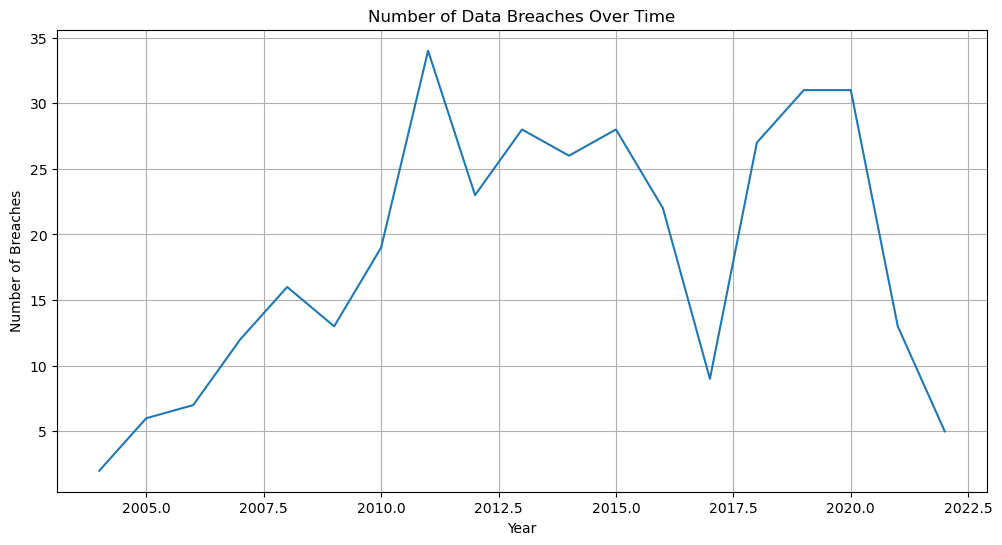

In [14]:
breaches_per_year = df['Year'].value_counts().sort_index()
breaches_per_year.plot(kind='line', figsize=(12, 6))
plt.title('Number of Data Breaches Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Breaches')
plt.grid(True)
plt.show()

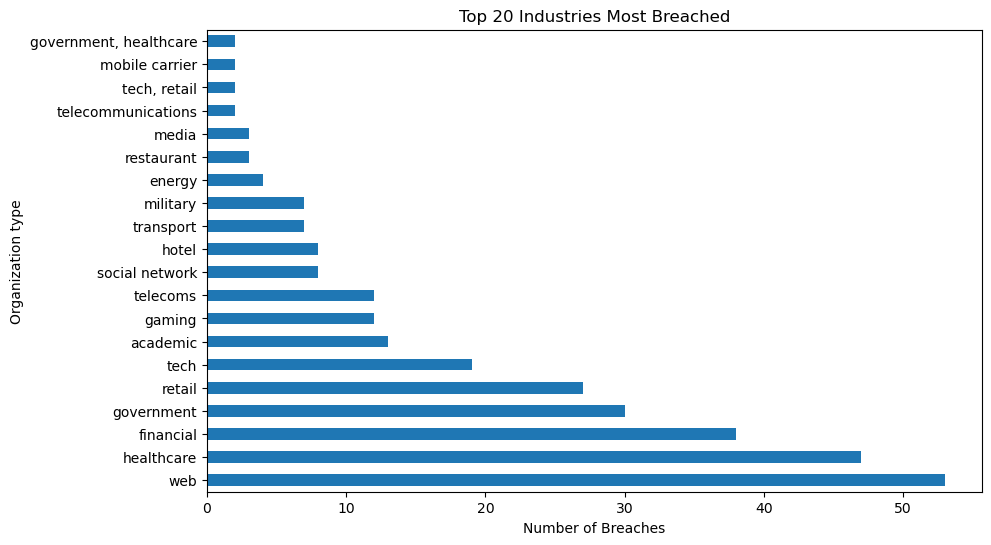

In [15]:
industry_breaches = df['Organization type'].value_counts().head(20)
industry_breaches.plot(kind='barh', figsize=(10, 6))
plt.title('Top 20 Industries Most Breached')
plt.xlabel('Number of Breaches')
plt.show()

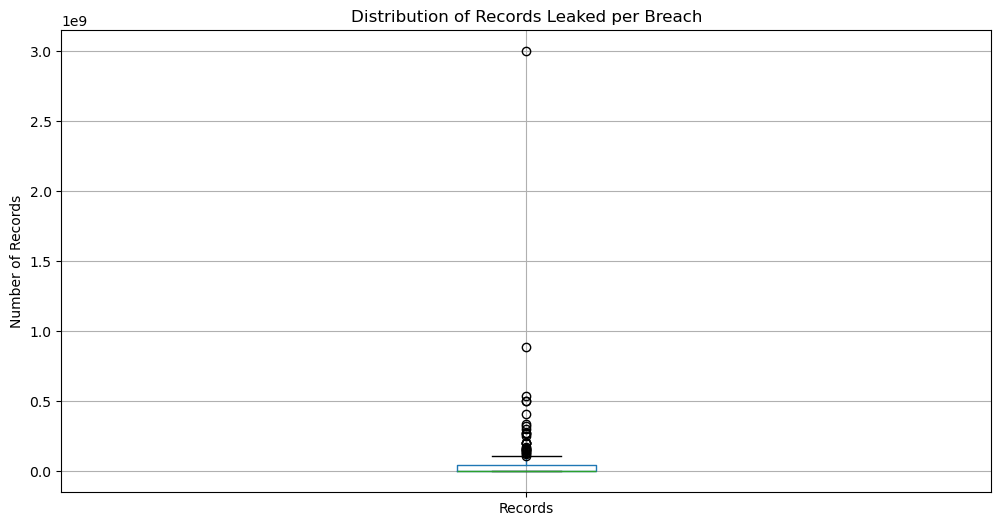

                         Entity       Records  Year
340                       Yahoo 3,000,000,000  2013
118  First American Corporation   885,000,000  2019
112                    Facebook   540,000,000  2019
176      Marriott International   500,000,000  2018
341                       Yahoo   500,000,000  2014
121      Friend Finder Networks   412,214,295  2016
106                     Exactis   340,000,000  2018
8                        Airtel   320,000,000  2019
285                  Truecaller   299,055,000  2019
191                     MongoDB   275,000,000  2019


In [16]:
# Distribution of records leaked
pd.options.display.float_format = '{:,.0f}'.format
plt.figure(figsize=(12, 6))
df['Records'].describe()

# Box plot to show outliers
df.boxplot(column='Records')
plt.title('Distribution of Records Leaked per Breach')
plt.ylabel('Number of Records')
plt.show()

# Largest breaches
print(df.nlargest(10, 'Records')[['Entity', 'Records', 'Year']])

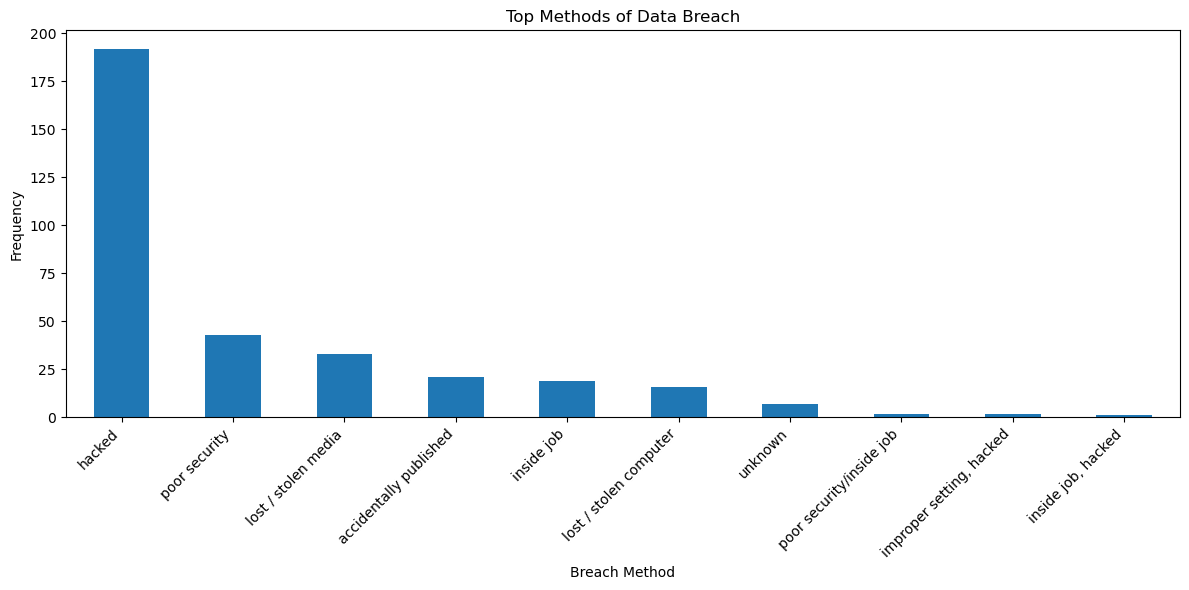

Method
hacked                     57
poor security              13
lost / stolen media        10
accidentally published      6
inside job                  6
lost / stolen computer      5
unknown                     2
poor security/inside job    1
improper setting, hacked    1
inside job, hacked          0
Name: count, dtype: float64


In [17]:
# Breach methods
breach_methods = df['Method'].value_counts().head(10)
breach_methods.plot(kind='bar', figsize=(12, 6))
plt.title('Top Methods of Data Breach')
plt.xlabel('Breach Method')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Percentage breakdown
breach_methods_pct = (breach_methods / breach_methods.sum() * 100)
print(breach_methods_pct)

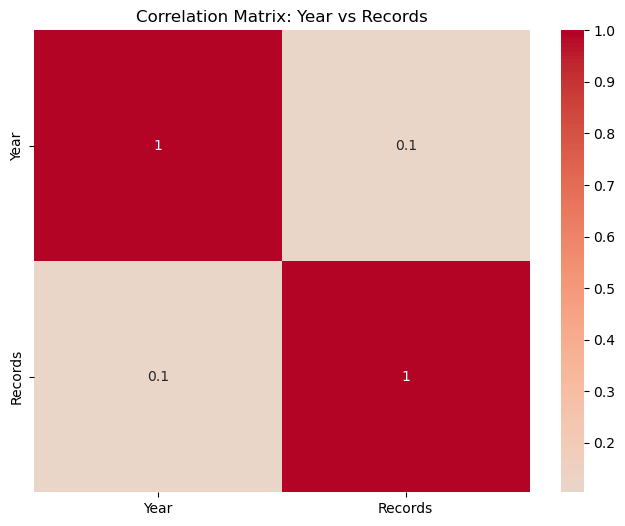

In [18]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Year', 'Records']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Year vs Records')
plt.show()

# skikit learn, Linear regression and Random forest

In [143]:
X = df[['Year']].values
y = df['Records'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train) 


lr_model = LinearRegression()
lr_model.fit(X_train, y_train) 
predictions = lr_model.predict(X_test)
print(predictions)

Training: 281, Testing: 71
[60112492.8476429  28253970.75833035 48165547.06415081  4360079.19134617
 40200916.54182243 16307024.97483826 32236286.01949501 32236286.01949501
 28253970.75833035 40200916.54182243 48165547.06415081 40200916.54182243
 60112492.8476429  72059438.63113499 64094808.10880756 60112492.8476429
 16307024.97483826 16307024.97483826 24271655.49716663 68077123.36997128
 24271655.49716663 40200916.54182243 44183231.8029871  40200916.54182243
 48165547.06415081 72059438.63113499 32236286.01949501 60112492.8476429
 64094808.10880756 40200916.54182243 76041753.89229965 36218601.28065872
 68077123.36997128 48165547.06415081 64094808.10880756 48165547.06415081
 52147862.32531548 52147862.32531548 24271655.49716663 60112492.8476429
 28253970.75833035 64094808.10880756 32236286.01949501 24271655.49716663
 56130177.58647919 60112492.8476429  44183231.8029871  48165547.06415081
 32236286.01949501 44183231.8029871  24271655.49716663 44183231.8029871
 40200916.54182243 52147862.

In [144]:
y_pred_lr = lr_model.predict(X)

# For specific years
future_years = np.array([[2025], [2026], [2027]])
future_pred_lr = lr_model.predict(future_years)

print(future_pred_lr)

[87988699.67579174 91971014.93695545 95953330.19812012]


In [145]:
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test) 

r2_train = r2_score(y_train, y_pred_rf_train)
r2_test = r2_score(y_test, y_pred_rf_test)

print(f"Training R²: {r2_train:.4f}")
print(f"Testing R²: {r2_test:.4f}")

Training R²: 0.0575
Testing R²: -0.1543


In [152]:
# y= intercept + (coef * x)

print(f"  Intercept (β₀): {lr_model.intercept_:,.2f}")
print(f"  Coefficient (β₁): {lr_model.coef_[0]:,.2f}")

print(f" The equation for the ski-kit learn for this model is ")
print(f"  Records = {lr_model.intercept_:,.0f} + ({lr_model.coef_[0]:,.0f} × Year)")

print(f"  This means that for every year that passes, breaches are predicted to increase by {lr_model.coef_[0]:,.0f} records")

  Intercept (β₀): -7,976,199,704.18
  Coefficient (β₁): 3,982,315.26
 The equation for the ski-kit learn for this model is 
  Records = -7,976,199,704 + (3,982,315 × Year)
  This means that for every year that passes, breaches are predicted to increase by 3,982,315 records


# future prediction

In [153]:
# Predict for specific years
future_years = np.array([[2020], [2025], [2027], [2029], [2031]])
predictions = lr_model.predict(future_years)

print('Predictions using the equation:')
for year, pred in zip(future_years.flatten(), predictions):
    print(f'  Year {int(year)}: {pred:,.0f} records')

Predictions using the equation:
  Year 2020: 68,077,123 records
  Year 2025: 87,988,700 records
  Year 2027: 95,953,330 records
  Year 2029: 103,917,961 records
  Year 2031: 111,882,591 records


# random forest 

In [154]:
feature_importance = rf_model.feature_importances_
print(f"Year importance: {feature_importance[0]:.4f}")

Year importance: 1.0000


In [155]:
y_pred_rf = rf_model.predict(X)


future_years = np.array([[2025], [2026], [2027]])
future_pred_rf = rf_model.predict(future_years)

print(future_pred_rf)

[1236213.58884057 1236213.58884057 1236213.58884057]


In [156]:
y_pred_lr = lr_model.predict(X_test)    # Predict on test
r2_lr = r2_score(y_test, y_pred_lr)     # Compare to test

y_pred_rf = rf_model.predict(X_test)    # Predict on test
r2_rf = r2_score(y_test, y_pred_rf)     # Compare to test

print(f"Linear Regression R^2: {r2_lr:.4f}")
print(f"Random Forest R^2: {r2_rf:.4f}")

Linear Regression R^2: 0.0308
Random Forest R^2: -0.1543


In [157]:
#improvements 
improvement_pct = ((r2_rf - r2_lr) / r2_lr) * 100
print(improvement_pct)

-601.0911972768268


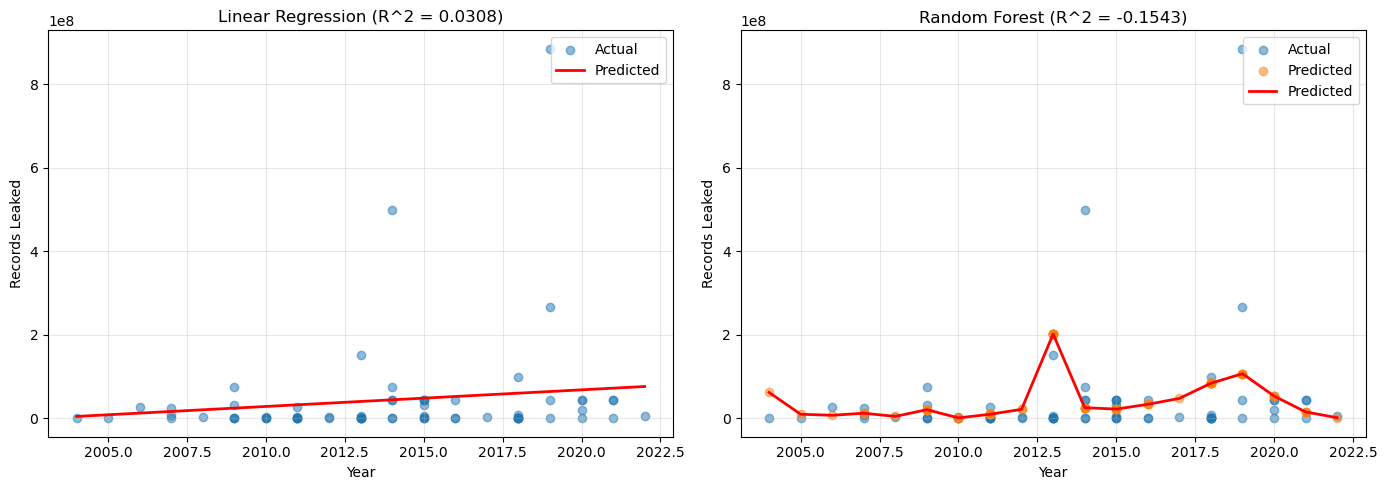

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(X_test, y_test, alpha=0.5, label='Actual')
axes[0].plot(np.sort(X_test, axis=0), lr_model.predict(np.sort(X_test, axis=0)), 'r-', linewidth=2, label='Predicted')
axes[0].set_title(f'Linear Regression (R^2 = {r2_lr:.4f})')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Records Leaked')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(X_test, y_test, alpha=0.5, label='Actual')
axes[1].scatter(X_test, y_pred_rf, alpha=0.5, label='Predicted')
axes[1].plot(np.sort(X_test, axis=0), rf_model.predict(np.sort(X_test, axis=0)), 'r-', linewidth=2, label='Predicted')
axes[1].set_title(f'Random Forest (R^2 = {r2_rf:.4f})')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Records Leaked')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis/Findings:

## Graphs Finding

- The number of breaches peaked in 2015-2016 with a notable drop in 2017, possibly reflecting increased security awareness post-major breaches

-  The web is the most frequently targeted medium for breaches, likely due to higher visibility and accessibility

- Yahoo experienced multiple breaches, with 2013 being a particularly affected year

- The top method of data breach is shown to be hacking, though this category may combine multiple attack techniques (SQL injection, credential theft, zero-days, etc.)



## Major Finding #1: Year is a Weak factor
The correlation between Year and Records is only 0.1. 

This means breach sizes vary widely even within the same year. for example 2020: Breaches ranged from 1M to 100M records where other factors may impact these records and number of breaches as well. 

 Linear Regression explains only **3.08%** of variance (R^2 = 0.0308)
- Breach sizes vary widely within the same year

- This means that Temporal trends alone are insufficient to predict breach magnitude. The size of a data breach is determined by organizational and contextual factors, not when the breach occurs.

## Major Finding #2: Linear Regression Outperforms Random Forest

The simpler linear model performs better than the more complex ensemble method.

Ski-kit showed the equation for the model to be Records = -7,976,199,704 + (3,982,315 × Year)

- Linear R^2: 0.0308
- Random Forest R²: -0.1543
- Improvement: -601.09 %
With only one weak feature (Year), Random Forest overfits to training data and fails on test data, resulting in negative R². Linear Regression's simplicity and mathematical approach make it more robust to limited, weak features.

More better and sophisticated models are not always better. With weak or insufficient features, simpler models that don't attempt to memorize patterns provide more reliable predictions. This is a valuable finding in itself.


## Recommendations for Future Work

1. **Add Organizational Feature**
   - Organization size (employees, revenue, customer base)

2. **Add more specific Breach Characteristics**
   - Breach method (Hacking, Insider Threat, Accidental)
   - attack types((SQL injection, credential theft, zero-days, etc.))
   - Industry sector classification 

3. **Consider Alternative Approaches**
   - Classification model (Small/Medium/Large breach) instead of exact numbers
   - Industry-specific models for Finance, Healthcare, etc.

4. **Feature Engineering**
   - Derive new features from existing data
   - Combine year with organizational factors

## Conclusion

This analysis demonstrates that single-factor predictive models are insufficient for real-world cybersecurity analysis. While year-based predictions performed poorly, this finding is scientifically valid and guides future research toward multi-factor approaches. The unexpected outperformance of the linear model shows that model complexity should match feature quality and data richness.